In [1]:
import pickle
import networkx as nx
import json
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def load_pickle(file):
    """
    load a pickle file into a local variable
    can be a pandas dataframe or dictionary
    """
    pickle_in = open(file, "rb")
    pickle_file = pickle.load(pickle_in)
    pickle_in.close()
    return pickle_file
    
def load_networkx(file):
    with open(file) as infile:
        network = json.load(infile)
    G = nx.readwrite.json_graph.cytoscape_graph(network)
    return G

In [3]:
paths = load_pickle('../results_mi/top_pathways_multinet_mi.pickle')
Gtot = load_networkx('../results_mi/multilevelnetwork_weighted_mi.json')
for _, _, d in Gtot.edges(data=True):
    d['weight'] = 1/d['weight']
G_gene = load_networkx('../results_mi/GENETIC_network_weighted_mi.json')
G_phen = load_networkx('../results_mi/PHENOTYPE_network_weighted_mi.json')

In [4]:
sources = list(sorted(G_gene.nodes()))
targets = list(sorted(G_phen.nodes()))
print(len(sources), len(targets))

7 12


In [5]:
paths_with_len = {}
for source in sources:
    paths_with_len[source] = {}
    for target in targets:
        paths_with_len[source][target] = nx.path_weight(Gtot, paths[source][target], weight="weight")

In [6]:
paths2 = paths.copy()
paths_with_len2 = paths_with_len.copy()

In [7]:
cont = 0
top10paths = []
top10len = []
while cont < 10:
    shortlen = 1000
    for source in sources:
        for target in targets:
            try:
                length = paths_with_len2[source][target]
                if length < shortlen:
                    shortlen = length
                    short_source = source
                    short_target = target
            except KeyError:
                pass
    top10paths.append(paths2[short_source][short_target])
    top10len.append(shortlen)
    del paths2[short_source][short_target], paths_with_len2[short_source][short_target]
    cont += 1

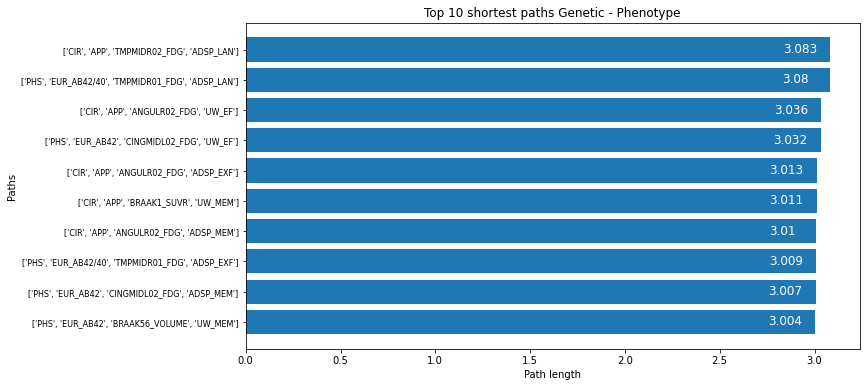

In [8]:
ypos = np.arange(len(top10paths))
plt.figure(figsize=(11, 6))
plt.barh(ypos, top10len)
for i, v in enumerate(top10len):
    plt.text(v - 0.25, i - 0.1, str(round(v, 3)), color='white', fontsize=12)
plt.yticks(ypos, labels=top10paths, fontsize=8)
plt.title('Top 10 shortest paths Genetic - Phenotype')
plt.ylabel('Paths')
plt.xlabel('Path length')
plt.savefig('../imagenes/top10.pdf')
plt.box(True)
plt.show()

In [9]:
paths2 = paths.copy()
paths_with_len2 = paths_with_len.copy()
cont = 0
top30paths = []
top30len = []
while cont < 30:
    shortlen = 1000
    for source in sources:
        for target in targets:
            try:
                length = paths_with_len2[source][target]
                if length < shortlen:
                    shortlen = length
                    short_source = source
                    short_target = target
            except KeyError:
                pass
    top30paths.append(paths2[short_source][short_target])
    top30len.append(shortlen)
    del paths2[short_source][short_target], paths_with_len2[short_source][short_target]
    cont += 1

In [10]:
pesos = {el:0 for el in Gtot.nodes()}
for p in top30paths:
    for el in p:
        pesos[el] += 1
pesos = {k: v/len(top30paths)*100 for k, v in pesos.items()}

for node in Gtot.nodes():
    if pesos[node] == 0:
        pesos.pop(node, None)

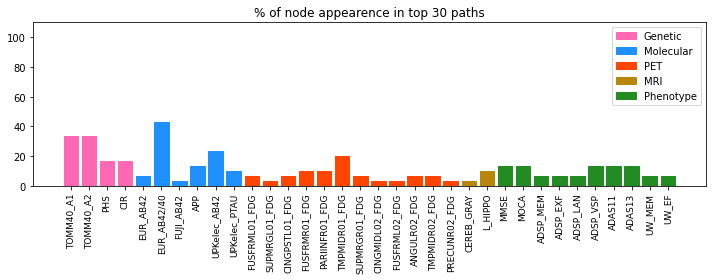

In [11]:
plt.figure(figsize=(10,4))
barlist = plt.bar(pesos.keys(), pesos.values())
for i in range(len(pesos.keys())):
    if i < 4:
        thecolor = 'hotpink'
    elif i < 10:
        thecolor = 'dodgerblue'
    elif i < 22:
        thecolor = 'orangered'
    elif i < 24:
        thecolor = 'darkgoldenrod'
    else:
        thecolor = 'forestgreen'
    barlist[i].set_color(thecolor)
colors = {'Genetic':'hotpink', 'Molecular':'dodgerblue', 'PET':'orangered', 'MRI':'darkgoldenrod', 'Phenotype':'forestgreen'}      
labels = list(colors.keys())
handles = [plt.Rectangle((0,0),1,1, color=colors[label]) for label in labels]
plt.legend(handles, labels)
plt.xticks(rotation=90, fontsize=9)
plt.ylim(0, 110)
plt.title('% of node appearence in top 30 paths')
plt.tight_layout()
plt.savefig('../imagenes/paths.png', format='png', dpi=600)
plt.show()

# NL, MCI, DEMENTIA

In [12]:
diags = ['nl', 'mci', 'dementia']

paths = load_pickle('../results_mi/top_pathways_multinet_mi_diag.pickle')
paths_with_len = {}
for diag in diags:
    # load networks
    G_gene_biom = load_networkx(f'../results_mi/GENETIC_MOLECULAR_{diag}_network_weighted_mi.json')
    G_gene_risk = load_networkx(f'../results_mi/GENETIC_RISKFACTORS_{diag}_network_weighted_mi.json')
    G_biom_pet = load_networkx(f'../results_mi/MOLECULAR_PET_{diag}_network_weighted_mi.json')
    G_biom_mri = load_networkx(f'../results_mi/MOLECULAR_MRI_{diag}_network_weighted_mi.json')
    G_biom_risk = load_networkx(f'../results_mi/MOLECULAR_RISKFACTORS_{diag}_network_weighted_mi.json')
    G_mri_pet = load_networkx(f'../results_mi/PET_MRI_{diag}_network_weighted_mi.json')
    G_pet_phen = load_networkx(f'../results_mi/PET_PHENOTYPE_{diag}_network_weighted_mi.json')
    G_mri_phen = load_networkx(f'../results_mi/MRI_PHENOTYPE_{diag}_network_weighted_mi.json')
    G_risk_pet = load_networkx(f'../results_mi/PET_RISKFACTORS_{diag}_network_weighted_mi.json')
    G_risk_mri = load_networkx(f'../results_mi/MRI_RISKFACTORS_{diag}_network_weighted_mi.json')
    G_risk_phen = load_networkx(f'../results_mi/RISKFACTORS_PHENOTYPE_{diag}_network_weighted_mi.json')
    # Multilevel network:
    Gtot = nx.compose(nx.compose(nx.compose(nx.compose(nx.compose(nx.compose(nx.compose(nx.compose(nx.compose(G_gene_biom, G_biom_pet), G_biom_mri), G_mri_pet), G_mri_phen), G_pet_phen), G_risk_phen), G_biom_risk), G_risk_pet), G_risk_mri)
    for _, _, d in Gtot.edges(data=True):
        d['weight'] = 1/d['weight']
    paths_with_len[diag] = {}
    for source in sources:
        paths_with_len[diag][source] = {}
        for target in targets:
            paths_with_len[diag][source][target] = nx.path_weight(Gtot, paths[diag][source][target], weight="weight")    

In [13]:
paths2 = paths.copy()
paths_with_len2 = paths_with_len.copy()

In [14]:
top30paths = {}
top30len = {}
for diag in diags:
    cont = 0
    top30paths_diag = []
    top30len_diag = []
    while cont < 30:
        shortlen = 1000
        for source in sources:
            for target in targets:
                try:
                    length = paths_with_len2[diag][source][target]
                    if length < shortlen:
                        shortlen = length
                        short_source = source
                        short_target = target
                except KeyError:
                    pass
        top30paths_diag.append(paths2[diag][short_source][short_target])
        top30len_diag.append(shortlen)
        del paths2[diag][short_source][short_target], paths_with_len2[diag][short_source][short_target]
        cont += 1
    top30paths[diag] = top30paths_diag
    top30len[diag] = top30len_diag

In [15]:
pesos_nl = {el:0 for el in Gtot.nodes()}
for p in top30paths['nl']:
    for el in p:
        pesos_nl[el] += 1
pesos_nl = {k: v/len(top30paths['nl'])*100 for k, v in pesos_nl.items()}

for node in Gtot.nodes():
    if pesos_nl[node] == 0:
        pesos_nl.pop(node, None)

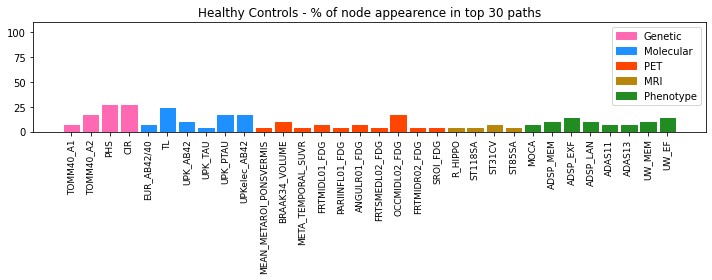

In [16]:
plt.figure(figsize=(10,4))
barlist = plt.bar(pesos_nl.keys(), pesos_nl.values())
for i in range(len(pesos_nl.keys())):
    if i < 4:
        thecolor = 'hotpink'
    elif i < 10:
        thecolor = 'dodgerblue'
    elif i < 20:
        thecolor = 'orangered'
    elif i < 24:
        thecolor = 'darkgoldenrod'
    else:
        thecolor = 'forestgreen'
    barlist[i].set_color(thecolor)
colors = {'Genetic':'hotpink', 'Molecular':'dodgerblue', 'PET':'orangered', 'MRI':'darkgoldenrod', 'Phenotype':'forestgreen'}      
labels = list(colors.keys())
handles = [plt.Rectangle((0,0),1,1, color=colors[label]) for label in labels]
plt.legend(handles, labels)
plt.xticks(rotation=90, fontsize=9)
plt.ylim(0, 110)
plt.title('Healthy Controls - % of node appearence in top 30 paths')
plt.tight_layout()
plt.savefig('../imagenes/paths_nl.png', format='png', dpi=600)
plt.show()

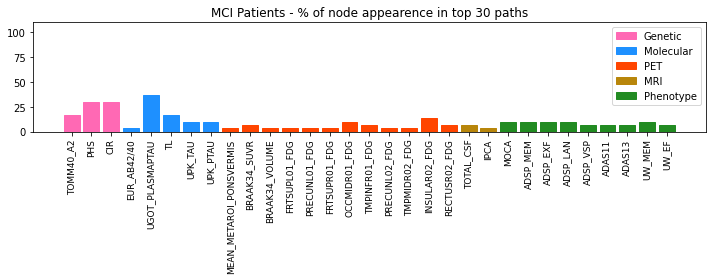

In [17]:
pesos_mci = {el:0 for el in Gtot.nodes()}
for p in top30paths['mci']:
    for el in p:
        pesos_mci[el] += 1
pesos_mci = {k: v/len(top30paths['mci'])*100 for k, v in pesos_mci.items()}

for node in Gtot.nodes():
    if pesos_mci[node] == 0:
        pesos_mci.pop(node, None)

plt.figure(figsize=(10,4))
barlist = plt.bar(pesos_mci.keys(), pesos_mci.values())
for i in range(len(pesos_mci.keys())):
    if i < 3:
        thecolor = 'hotpink'
    elif i < 8:
        thecolor = 'dodgerblue'
    elif i < 20:
        thecolor = 'orangered'
    elif i < 22:
        thecolor = 'darkgoldenrod'
    else:
        thecolor = 'forestgreen'
    barlist[i].set_color(thecolor)
colors = {'Genetic':'hotpink', 'Molecular':'dodgerblue', 'PET':'orangered', 'MRI':'darkgoldenrod', 'Phenotype':'forestgreen'}      
labels = list(colors.keys())
handles = [plt.Rectangle((0,0),1,1, color=colors[label]) for label in labels]
plt.legend(handles, labels)
plt.xticks(rotation=90, fontsize=9)
plt.ylim(0, 110)
plt.title('MCI Patients - % of node appearence in top 30 paths')
plt.tight_layout()
plt.savefig('../imagenes/paths_mci.png', format='png', dpi=600)
plt.show()

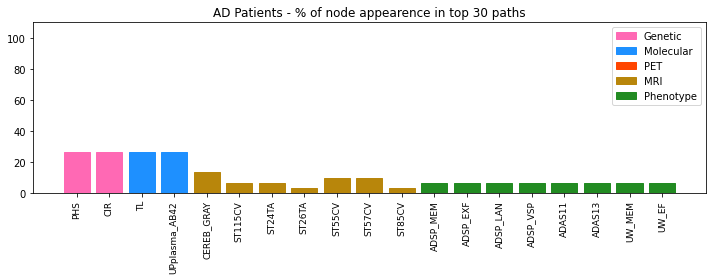

In [18]:
pesos_dementia = {el:0 for el in Gtot.nodes()}
for p in top30paths['dementia']:
    for el in p:
        pesos_dementia[el] += 1
pesos_dementia = {k: v/len(top30paths['dementia'])*100 for k, v in pesos_dementia.items()}

for node in Gtot.nodes():
    if pesos_dementia[node] == 0:
        pesos_dementia.pop(node, None)

plt.figure(figsize=(10,4))
barlist = plt.bar(pesos_dementia.keys(), pesos_dementia.values())
for i in range(len(pesos_dementia.keys())):
    if i < 2:
        thecolor = 'hotpink'
    elif i < 4:
        thecolor = 'dodgerblue'
    elif i < 11:
        thecolor = 'darkgoldenrod'
    else:
        thecolor = 'forestgreen'
    barlist[i].set_color(thecolor)
colors = {'Genetic':'hotpink', 'Molecular':'dodgerblue', 'PET':'orangered', 'MRI':'darkgoldenrod', 'Phenotype':'forestgreen'}      
labels = list(colors.keys())
handles = [plt.Rectangle((0,0),1,1, color=colors[label]) for label in labels]
plt.legend(handles, labels)
plt.xticks(rotation=90, fontsize=9)
plt.ylim(0, 110)
plt.title('AD Patients - % of node appearence in top 30 paths')
plt.tight_layout()
plt.savefig('../imagenes/paths_dementia.png', format='png', dpi=600)
plt.show()